In [112]:
import uproot, numpy as np
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
print(uproot.__version__)

5.7.5


Fetch root file generated from manual scoring within carbon volume via the analysis manager

In [113]:
# Fetch
f = uproot.open("../build/target_run.root")          # adjust path to where the run wrote it
vals_MeV, edges_mm = f["EdepZ"].to_numpy()           # 300 bin contents [MeV], 301 edges [mm]

In [123]:
# Normalize per ion, N from the data (gated first entries), never a memorized constant
b = f["beam"].arrays(library="np")
m = b["E"] > 20.0                                    # first-entry gate [keV]
N = int(m.sum())

dEdep_keV   = vals_MeV * 1e3 / N                        # -> keV per ion per bin
centers  = 0.5 * (edges_mm[1:] + edges_mm[:-1]) * 1e6  # bin centers, mm -> nm

In [124]:
# ---------- Mesh CSV ----------
d = np.loadtxt("../edep_mesh.csv", delimiter=",", comments="#")
# columns: iX, iY, depth, total(value)[keV], total(val^2), entries
depth    = d[:, 2].astype(int)
mesh_keV = d[:, 3] / N                               # already keV; per ion
order    = np.argsort(depth)                        # guarantee depth order
depth, mesh_keV = depth[order], mesh_keV[order]
mesh_z   = (depth + 0.5) * 0.5                       # voxel centers in nm (0.5 nm voxels)

In [134]:
# Per-voxel statistical error from the val^2 column
sum_v  = d[:, 3][order]
sum_v2 = d[:, 4][order]
n_ent  = d[:, 5][order]
with np.errstate(invalid="ignore", divide="ignore"):
    sigma = np.sqrt(np.maximum(sum_v2 - sum_v**2 / np.maximum(n_ent, 1), 0)) / N

Manual Scoring integral:   23.567 keV/ion
Mesh integral: 24.690 keV/ion
max |residual|: 0.0919 keV


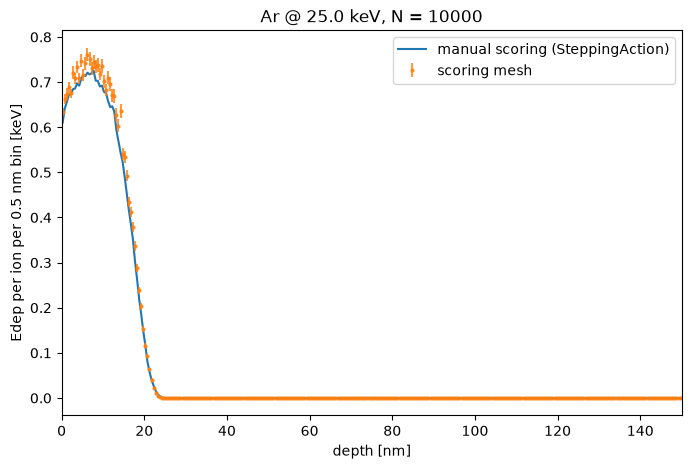

In [133]:
# ---------- Overlay ----------
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(centers, dEdep_keV, label="manual scoring (SteppingAction)", color="C0")
ax.errorbar(mesh_z, mesh_keV, yerr=sigma, fmt=".", ms=4, color="C1",
            label="scoring mesh", alpha=0.8)
ax.set_xlabel("depth [nm]")
ax.set_ylabel("Edep per ion per 0.5 nm bin [keV]")
ax.set_xlim(0, 150)
ax.legend()
ax.set_title(f"Ar @ {b['E'][m].mean():.1f} keV, N = {N}")

# ---------- The quantitative verdict ----------
print(f"Manual Scoring integral:   {dEdep_keV.sum():.3f} keV/ion")
print(f"Mesh integral: {mesh_keV.sum():.3f} keV/ion")
resid = (dEdep_keV - mesh_keV)
print(f"max |residual|: {np.abs(resid).max():.4f} keV")


Scoring Run w/out voxel boundaries - checking 

Manual Scoring integral:   23.567 keV/ion


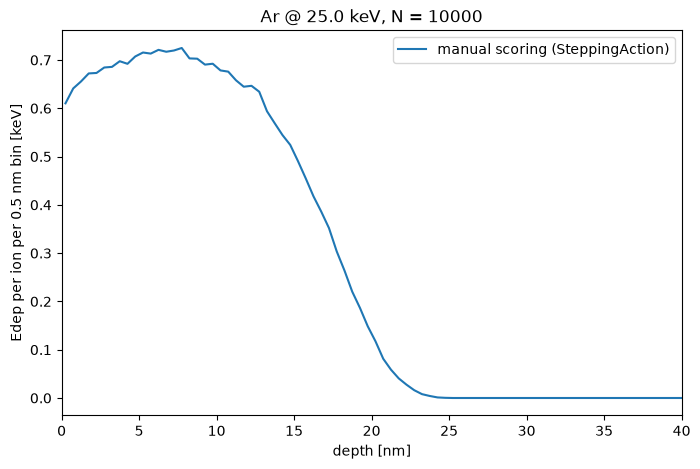

In [131]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(centers, dEdep_keV, label="manual scoring (SteppingAction)", color="C0")
ax.set_xlabel("depth [nm]")
ax.set_ylabel("Edep per ion per 0.5 nm bin [keV]")
ax.set_xlim(0, 40)
ax.legend()
ax.set_title(f"Ar @ {b['E'][m].mean():.1f} keV, N = {N}")

print(f"Manual Scoring integral:   {dEdep_keV.sum():.3f} keV/ion")

In [119]:
geantInput = {"x [mm]": (0, 0.5), "y [mm]": (0, 0.5),
       "xp [mrad]": (0.2, 0.1), "yp [mrad]": (0.2, 0.1),
       "E [keV]": (25.0, 0.25)}
data = {"x [mm]": b["x"][m], "y [mm]": b["y"][m],
        "xp [mrad]": b["xp"][m]*1e3, "yp [mrad]": b["yp"][m]*1e3,
        "E [keV]": b["E"][m]}
print(f"{'qty':10s} {'geantInput mu':>8s} {'geantInput sig':>8s} {'fit mu':>8s} {'fit sig':>8s}")
for k in geantInput:
    mu, sig = norm.fit(data[k])
    print(f"{k:10s} {geantInput[k][0]:8.3f} {geantInput[k][1]:8.3f} {mu:8.3f} {sig:8.3f}")

qty        geantInput mu geantInput sig   fit mu  fit sig
x [mm]        0.000    0.500   -0.005    0.500
y [mm]        0.000    0.500   -0.000    0.504
xp [mrad]     0.200    0.100    0.199    0.100
yp [mrad]     0.200    0.100    0.200    0.100
E [keV]      25.000    0.250   24.996    0.251


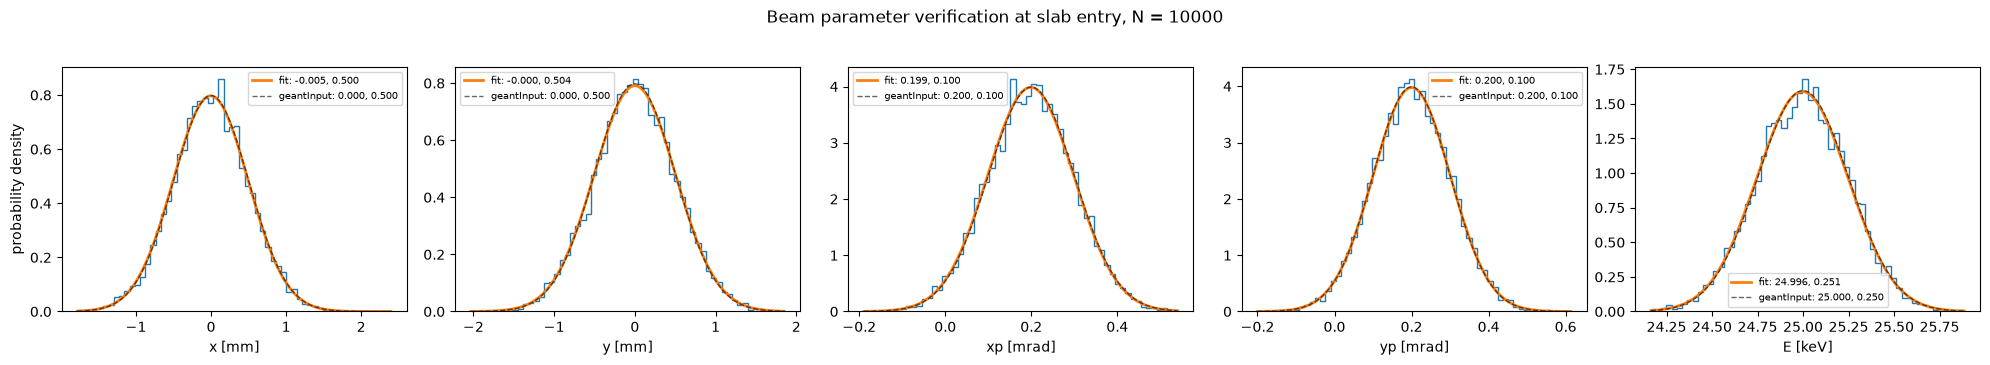

In [120]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, (k, (gmu, gsig)) in zip(axes, geantInput.items()):
    d = data[k]
    mu, sig = norm.fit(d)
    # histogram, density-normalized so the pdf overlays directly
    n, bins, _ = ax.hist(d, bins=60, density=True, histtype="step", color="C0")
    xs = np.linspace(bins[0], bins[-1], 300)
    ax.plot(xs, norm.pdf(xs, mu, sig), "C1-", lw=2,
            label=f"fit: {mu:.3f}, {sig:.3f}")
    ax.plot(xs, norm.pdf(xs, gmu, gsig), "k--", lw=1, alpha=0.6,
            label=f"geantInput: {gmu:.3f}, {gsig:.3f}")
    ax.set_xlabel(k)
    ax.legend(fontsize=7)
axes[0].set_ylabel("probability density")
fig.suptitle(f"Beam parameter verification at slab entry, N = {N}", y=1.03)
plt.tight_layout()

### TRIM Comparison

Energy To Recoils -> Nuclear Stopping/Elastic Interactions. Dominant Energy Loss Mechanism.

Peak unity conversion (TRIM $\text{eV}/\AA{}$) -> (Geant4 $\text{KeV}/\text{nm}$). Binning effect from Geant4 plot, take as rough sanity check not real validation

- Geant4 Peak: $~0.75 \text{KeV}/\text{nm}$ PER 0.5nm bins
- TRIM Peak: $~0.65 \text{KeV}/\text{nm}$

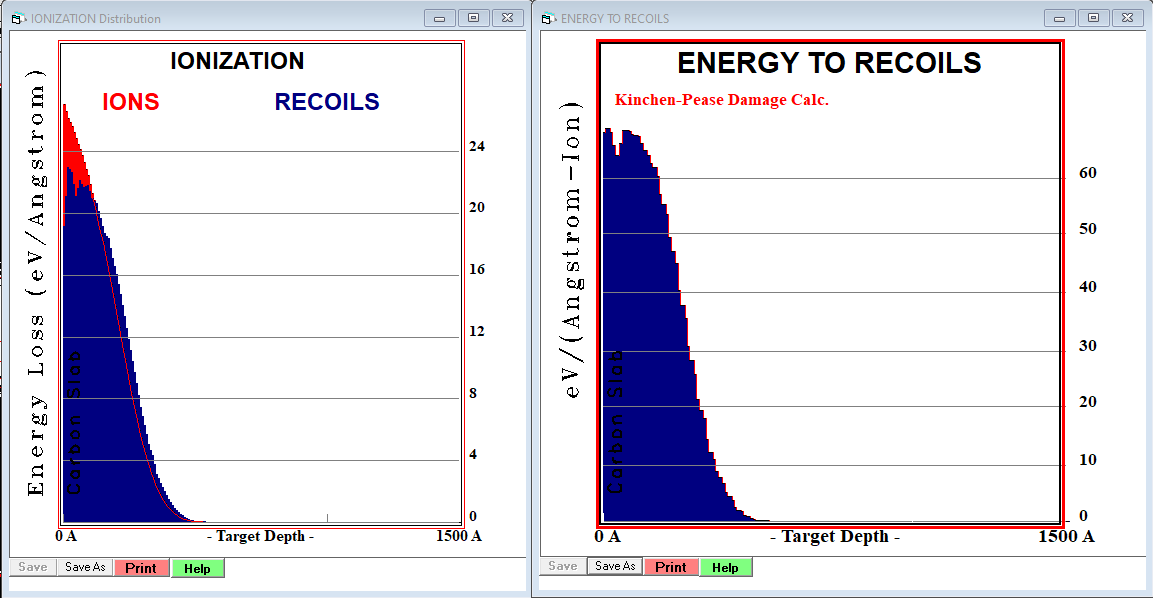
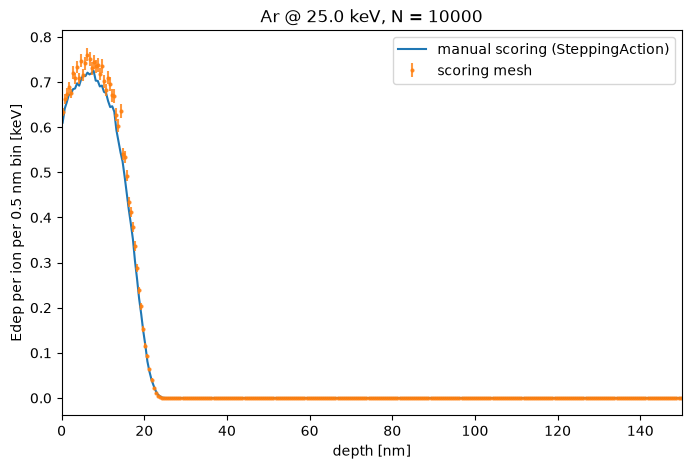


 ==================================================================
              SRIM version ---> SRIM-2013.00
              Calc. date   ---> July 12, 2026 
 ==================================================================

 Disk File Name = SRIM Outputs\Argon in Carbon.txt

 Ion = Argon [18] , Mass = 39.962 amu

 Target Density =  1.9000E+00 g/cm3 = 9.5261E+22 atoms/cm3
 ======= Target  Composition ========
    Atom   Atom   Atomic    Mass     
    Name   Numb   Percent   Percent  
    ----   ----   -------   -------  
      C      6    100.00    100.00   
 ====================================
 Bragg Correction = 0.00%
 Stopping Units =  keV / micron   
 See bottom of Table for other Stopping units 

        Ion        dE/dx      dE/dx     Projected  Longitudinal   Lateral
       Energy      Elec.      Nuclear     Range     Straggling   Straggling
  --------------  ---------- ---------- ----------  ----------  ----------
  25.00 keV   2.731E+02  6.726E+02     285 A        71 A        57 A   
-----------------------------------------------------------
 Multiply Stopping by        for Stopping Units
 -------------------        ------------------
  1.0000E-01                 eV / Angstrom 
  1.0000E+00                keV / micron   
  1.0000E+00                MeV / mm       
  5.2633E-03                keV / (ug/cm2) 
  5.2633E-03                MeV / (mg/cm2) 
  5.2633E+00                keV / (mg/cm2) 
  1.0497E-01                 eV / (1E15 atoms/cm2)
  4.7643E-04                L.S.S. reduced units
 ==================================================================
 (C) 1984,1989,1992,1998,2008 by J.P. Biersack and J.F. Ziegler

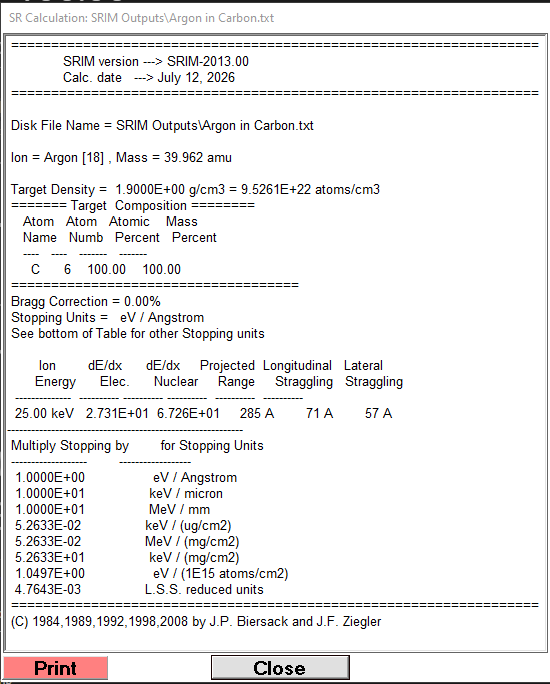

Carbon density in both -> $1.9 \text{g / cm}^3$

SRIM Stopping Power:

$(dE/dx)|_{E} = 0.2731 \text{KeV/nm}$

$(dE/dx)|_{N} = 0.6726 \text{KeV/nm}$

GEANT4 Stopping Power From EMCalculator

$(dE/dx)|_{E} = 0.104 \text{KeV/nm}$

$(dE/dx)|_{N} = 0.682 \text{KeV/nm}$